## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [11]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [12]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

Shape: (517, 13)

Data Types:
X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

Missing Values: 0

Summary Statistics:
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.

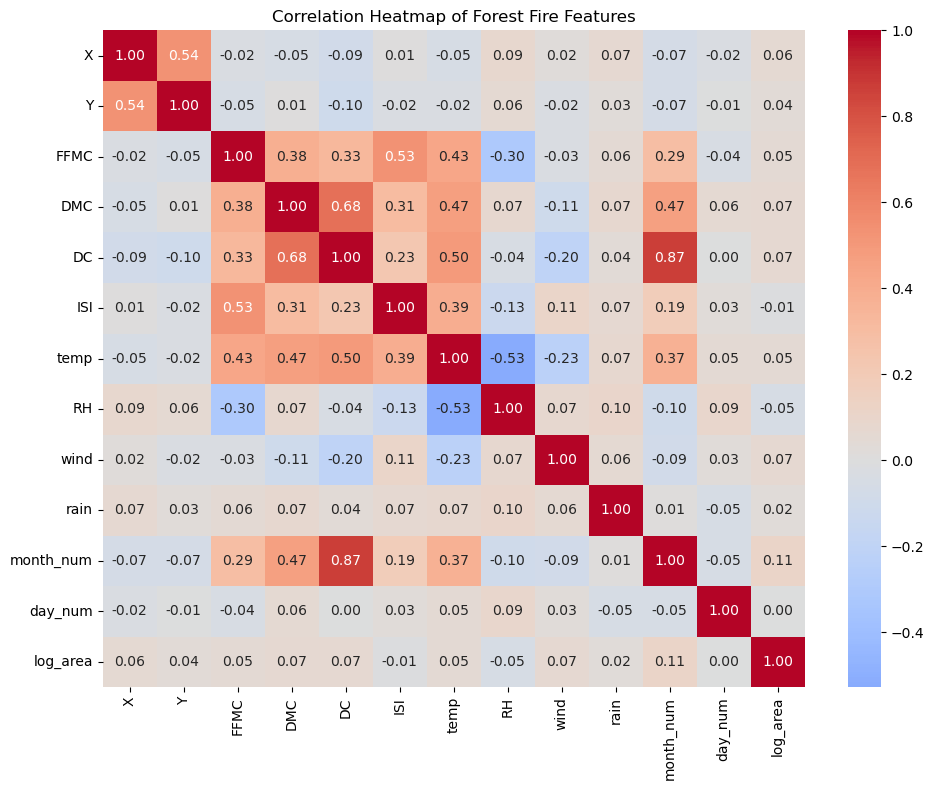

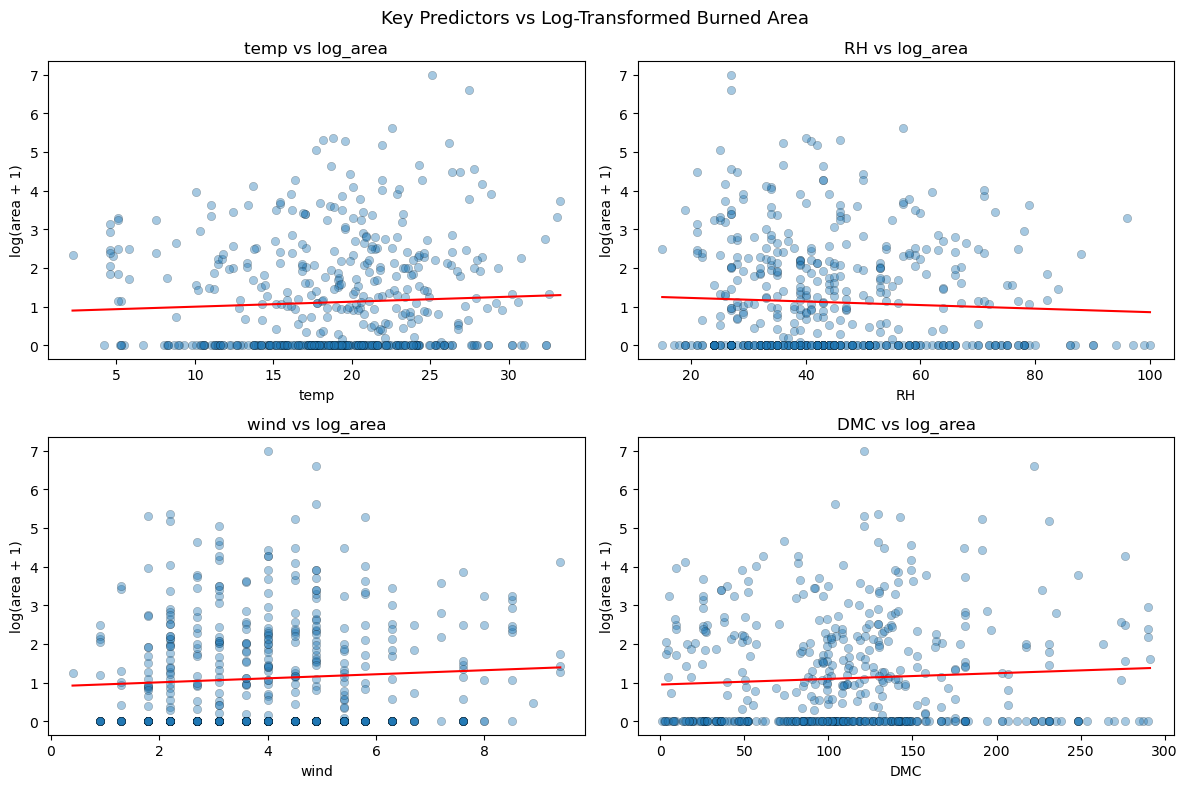

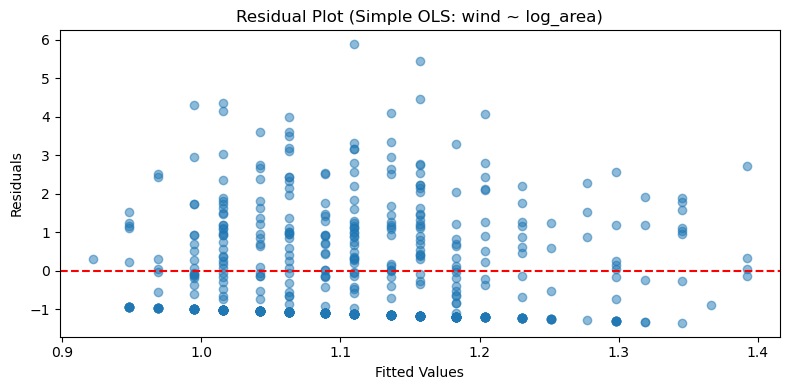


EDA complete.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Loading the CSV
df = pd.read_csv('forestfires.csv')

# Dataset structure
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:', df.isnull().sum().sum())
print('\nSummary Statistics:')
print(df.describe())

# Log-transform target (area is heavily right-skewed)
df['log_area'] = np.log1p(df['area'])

# Encoding month and day as numeric for correlation
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order   = ['mon','tue','wed','thu','fri','sat','sun']
df['month_num'] = df['month'].map({m: i+1 for i, m in enumerate(month_order)})
df['day_num']   = df['day'].map({d: i+1 for i, d in enumerate(day_order)})

# Correlation with log_area
numeric_cols = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain','month_num','day_num','log_area']
corr = df[numeric_cols].corr()
print('\nCorrelations with log_area:')
print(corr['log_area'].drop('log_area').sort_values(ascending=False))

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Forest Fire Features')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=100)
plt.show()

# Scatterplots: key predictors vs log_area
key_preds = ['temp', 'RH', 'wind', 'DMC']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), key_preds):
    ax.scatter(df[col], df['log_area'], alpha=0.4, edgecolors='k', linewidths=0.3)
    m, b = np.polyfit(df[col], df['log_area'], 1)
    ax.plot(sorted(df[col]), [m*x+b for x in sorted(df[col])], color='red')
    ax.set_xlabel(col)
    ax.set_ylabel('log(area + 1)')
    ax.set_title(f'{col} vs log_area')
plt.suptitle('Key Predictors vs Log-Transformed Burned Area', fontsize=13)
plt.tight_layout()
plt.savefig('scatterplots.png', dpi=100)
plt.show()

# Residual plot (using simple OLS with wind as single predictor)
X_simple = sm.add_constant(df[['wind']])
model_simple = sm.OLS(df['log_area'], X_simple).fit()
residuals = model_simple.resid
fitted = model_simple.fittedvalues

plt.figure(figsize=(8, 4))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Simple OLS: wind ~ log_area)')
plt.tight_layout()
plt.savefig('residual_simple.png', dpi=100)
plt.show()

print('\nEDA complete.')

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [14]:
from sklearn.preprocessing import LabelEncoder

# One-hot encode month and day (indicator variables)
df_model = pd.get_dummies(df.drop(columns=['area','month_num','day_num']), columns=['month','day'], drop_first=True)
# Convert boolean dummy columns to int to avoid dtype issues in statsmodels
bool_cols = [c for c in df_model.columns if df_model[c].dtype == bool]
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Key predictors (numeric only first for baseline)
key_preds = ['temp','RH','wind','FFMC','DMC','DC','ISI']
y = df['log_area']

# Model 1: Baseline multiple linear regression
X1 = sm.add_constant(df[key_preds].astype(float))
model1 = sm.OLS(y, X1).fit()
print('=== Model 1: Baseline MLR ===')
print(model1.summary())

# Model 2: Quadratic (nonlinear) terms for temp and wind
df['temp2'] = df['temp'] ** 2
df['wind2'] = df['wind'] ** 2
quad_preds = key_preds + ['temp2', 'wind2']
X2 = sm.add_constant(df[quad_preds].astype(float))
model2 = sm.OLS(y, X2).fit()
print('\n=== Model 2: MLR + Quadratic Terms ===')
print(model2.summary())

# Model 3: Add interaction term (temp * RH) and log transform skewed predictors
df['temp_RH']   = df['temp'] * df['RH']
df['log_DMC']   = np.log1p(df['DMC'])
df['log_DC']    = np.log1p(df['DC'])
df['log_rain']  = np.log1p(df['rain'])

extended_preds = ['temp','RH','wind','FFMC','log_DMC','log_DC','ISI','temp_RH','temp2','wind2']
X3 = sm.add_constant(df[extended_preds].astype(float))
model3 = sm.OLS(y, X3).fit()
print('\n=== Model 3: MLR + Interactions + Log Transforms ===')
print(model3.summary())

# Model 4: Include indicator variables (month & day dummies)
indicator_cols = [c for c in df_model.columns if c.startswith('month_') or c.startswith('day_')]
full_preds = extended_preds + indicator_cols
# Rebuild df with new engineered features
for col in ['temp2','wind2','temp_RH','log_DMC','log_DC','log_rain']:
    df_model[col] = df[col].values
X4 = sm.add_constant(df_model[full_preds].astype(float))
model4 = sm.OLS(y, X4).fit()
print('\n=== Model 4: MLR + Interactions + Log Transforms + Indicator Variables ===')
print(model4.summary())

print('\nModel fitting complete.')

=== Model 1: Baseline MLR ===
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.445
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.185
Time:                        18:51:19   Log-Likelihood:                -901.38
No. Observations:                 517   AIC:                             1819.
Df Residuals:                     509   BIC:                             1853.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1547 

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

=== Model Comparison ===
                  Model     R2  Adj_R2     AIC     BIC
     Model 1 (Baseline) 0.0195  0.0060 1818.77 1852.75
   Model 2 (+Quadratic) 0.0399  0.0228 1811.91 1854.39
Model 3 (+Interactions) 0.0443  0.0254 1811.51 1858.24
  Model 4 (+Indicators) 0.0766  0.0256 1827.72 1946.67


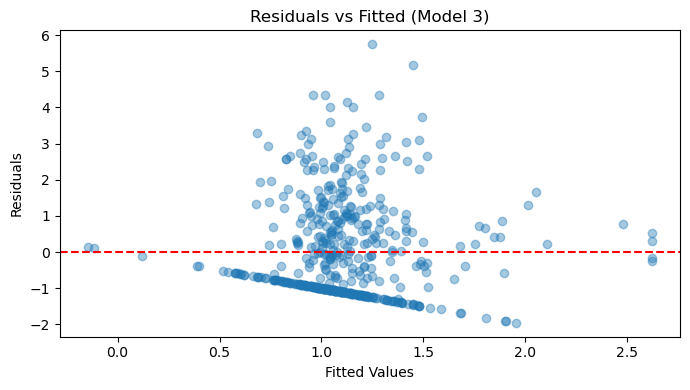

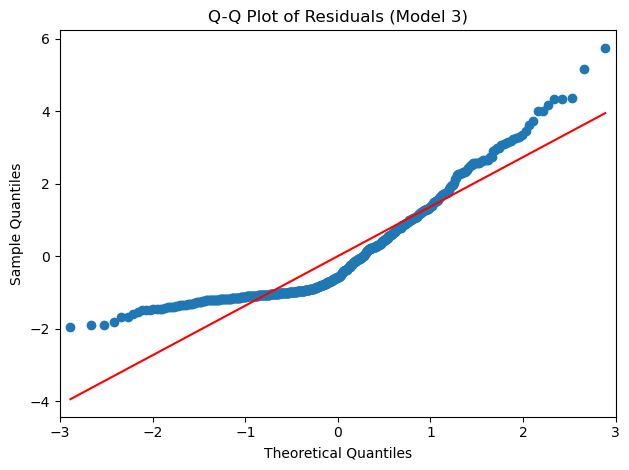

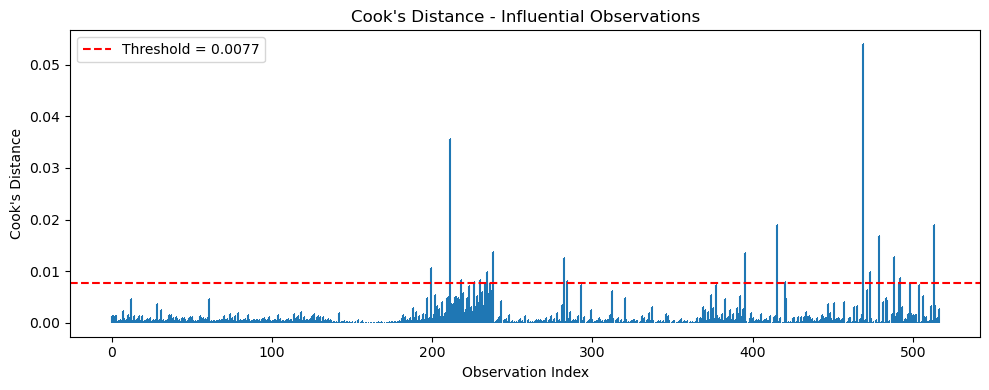


Influential observations (Cook's D > 0.0077): 19

Diagnostics complete.


In [15]:
# Compare model metrics
models = {'Model 1 (Baseline)': model1, 'Model 2 (+Quadratic)': model2,
          'Model 3 (+Interactions)': model3, 'Model 4 (+Indicators)': model4}

metrics = []
for name, m in models.items():
    metrics.append({'Model': name, 'R2': round(m.rsquared, 4),
                    'Adj_R2': round(m.rsquared_adj, 4),
                    'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})

metrics_df = pd.DataFrame(metrics)
print('=== Model Comparison ===')
print(metrics_df.to_string(index=False))

# Use Model 3 for diagnostics (best balance)
best_model = model3
residuals  = best_model.resid
fitted     = best_model.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(7, 4))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Model 3)')
plt.tight_layout()
plt.savefig('resid_vs_fitted.png', dpi=100)
plt.show()

# Q-Q Plot
fig = sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals (Model 3)')
plt.tight_layout()
plt.savefig('qq_plot.png', dpi=100)
plt.show()

# Cook's Distance
influence = best_model.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(y)

plt.figure(figsize=(10, 4))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=',', basefmt=' ')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance - Influential Observations")
plt.legend()
plt.tight_layout()
plt.savefig('cooks_distance.png', dpi=100)
plt.show()

n_influential = (cooks_d > threshold).sum()
print(f'\nInfluential observations (Cook\'s D > {threshold:.4f}): {n_influential}')
print('\nDiagnostics complete.')

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

=== Ridge Regression (alpha=1.0) ===
  temp           : -1.2610
  RH             : -0.2729
  wind           : 0.0613
  FFMC           : 0.0615
  log_DMC        : 0.0720
  log_DC         : 0.0986
  ISI            : -0.1174
  temp_RH        : 0.2226
  temp2          : 1.0833
  wind2          : 0.0457
  Intercept  : 1.1110
  Train MSE  : 1.8666
  CV MSE     : 2.2352

=== Lasso Regression (alpha=0.1) ===
  temp           : 0.0000
  RH             : -0.0000
  wind           : 0.0000
  FFMC           : 0.0000
  log_DMC        : 0.0000
  log_DC         : 0.0000
  ISI            : -0.0000
  temp_RH        : -0.0000
  temp2          : 0.0131
  wind2          : 0.0000
  Intercept  : 1.1110
  Train MSE  : 1.9490
  CV MSE     : 2.2019
  Zeroed out : 9 features


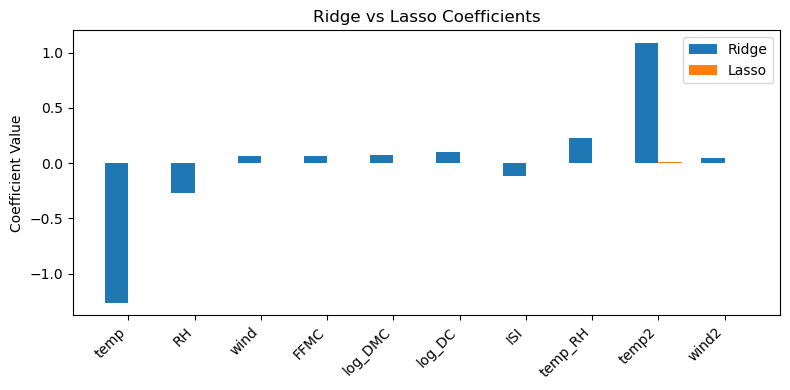


Regularization complete.


In [16]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Preparing features for regularization
reg_preds = ['temp','RH','wind','FFMC','log_DMC','log_DC','ISI','temp_RH','temp2','wind2']
X_reg = df[reg_preds].values
y_reg = df['log_area'].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_reg)
ridge_preds = ridge.predict(X_scaled)
ridge_mse   = mean_squared_error(y_reg, ridge_preds)

ridge_cv = cross_val_score(ridge, X_scaled, y_reg, cv=5, scoring='neg_mean_squared_error')
ridge_cv_mse = -ridge_cv.mean()

print('=== Ridge Regression (alpha=1.0) ===')
for name, coef in zip(reg_preds, ridge.coef_):
    print(f'  {name:15s}: {coef:.4f}')
print(f'  Intercept  : {ridge.intercept_:.4f}')
print(f'  Train MSE  : {ridge_mse:.4f}')
print(f'  CV MSE     : {ridge_cv_mse:.4f}')

# Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_scaled, y_reg)
lasso_preds = lasso.predict(X_scaled)
lasso_mse   = mean_squared_error(y_reg, lasso_preds)

lasso_cv = cross_val_score(lasso, X_scaled, y_reg, cv=5, scoring='neg_mean_squared_error')
lasso_cv_mse = -lasso_cv.mean()

print('\n=== Lasso Regression (alpha=0.1) ===')
for name, coef in zip(reg_preds, lasso.coef_):
    print(f'  {name:15s}: {coef:.4f}')
print(f'  Intercept  : {lasso.intercept_:.4f}')
print(f'  Train MSE  : {lasso_mse:.4f}')
print(f'  CV MSE     : {lasso_cv_mse:.4f}')
print(f'  Zeroed out : {(lasso.coef_ == 0).sum()} features')

# Comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(reg_preds))
width = 0.35
ax.bar(x - width/2, ridge.coef_, width, label='Ridge')
ax.bar(x + width/2, lasso.coef_, width, label='Lasso')
ax.set_xticks(x)
ax.set_xticklabels(reg_preds, rotation=45, ha='right')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge vs Lasso Coefficients')
ax.legend()
plt.tight_layout()
plt.savefig('ridge_vs_lasso.png', dpi=100)
plt.show()

print('\nRegularization complete.')

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [17]:
from sklearn.preprocessing import StandardScaler

# Create binary target: 1 = fire size above median (excluding zeros), 0 = below
median_area = df.loc[df['area'] > 0, 'area'].median()
print(f'Median burned area (non-zero): {median_area:.2f} ha')

df['fire_binary'] = (df['area'] >= median_area).astype(int)
print('Class distribution:')
print(df['fire_binary'].value_counts())

# Select predictors and scale
clf_preds = ['temp','RH','wind','FFMC','log_DMC','log_DC','ISI']
X_clf = df[clf_preds].values
y_clf = df['fire_binary'].values

scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

print('\nFeature matrix shape:', X_clf_scaled.shape)
print('Target shape:', y_clf.shape)
print('\nBinary target preparation complete.')

Median burned area (non-zero): 6.37 ha
Class distribution:
fire_binary
0    382
1    135
Name: count, dtype: int64

Feature matrix shape: (517, 7)
Target shape: (517,)

Binary target preparation complete.


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

=== Logistic Regression Coefficients ===
  temp        : -0.1259
  RH          : -0.2386
  wind        : 0.0666
  FFMC        : 0.0573
  log_DMC     : -0.0113
  log_DC      : 0.1129
  ISI         : -0.0253
  Intercept  : -1.0449

Accuracy: 0.7404

Classification Report:
              precision    recall  f1-score   support

    Low Fire       0.74      1.00      0.85        77
   High Fire       0.00      0.00      0.00        27

    accuracy                           0.74       104
   macro avg       0.37      0.50      0.43       104
weighted avg       0.55      0.74      0.63       104



c:\Users\xaviers\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\xaviers\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\xaviers\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


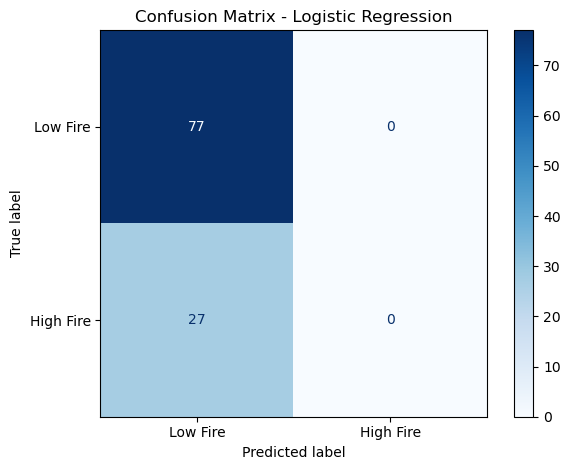


Logistic regression evaluation complete.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Coefficients and intercept
print('=== Logistic Regression Coefficients ===')
for feat, coef in zip(clf_preds, log_reg.coef_[0]):
    print(f'  {feat:12s}: {coef:.4f}')
print(f'  Intercept  : {log_reg.intercept_[0]:.4f}')

# Predictions
y_prob  = log_reg.predict_proba(X_test)[:, 1]
y_pred  = log_reg.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Fire','High Fire']))

# Confusion matrix
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Fire','High Fire'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

print('\nLogistic regression evaluation complete.')

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

=== Variance Inflation Factor (VIF) ===
Feature        VIF
 log_DC 131.027428
log_DMC 122.955143
   FFMC  70.854896
   temp  29.970417
     RH  11.893241
    ISI   6.660697
   wind   6.514509

Rule of thumb: VIF > 5 suggests notable multicollinearity; VIF > 10 is severe.


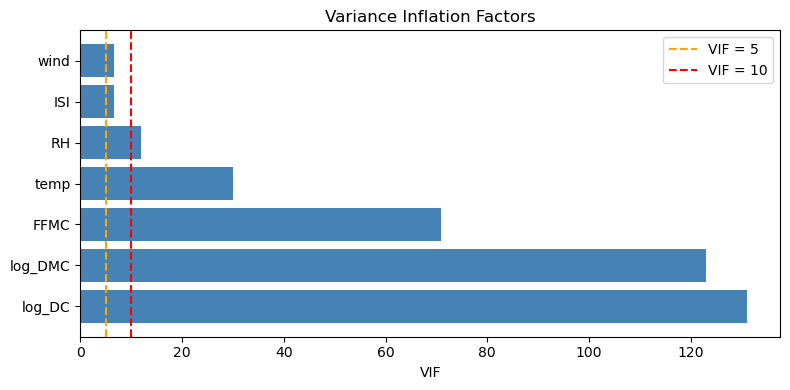


VIF check complete.


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF for classification predictors
X_vif = df[clf_preds].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = clf_preds
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                       for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== Variance Inflation Factor (VIF) ===')
print(vif_data.to_string(index=False))
print('\nRule of thumb: VIF > 5 suggests notable multicollinearity; VIF > 10 is severe.')

# VIF bar chart
plt.figure(figsize=(8, 4))
plt.barh(vif_data['Feature'], vif_data['VIF'], color='steelblue')
plt.axvline(5,  color='orange', linestyle='--', label='VIF = 5')
plt.axvline(10, color='red',    linestyle='--', label='VIF = 10')
plt.xlabel('VIF')
plt.title('Variance Inflation Factors')
plt.legend()
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=100)
plt.show()

print('\nVIF check complete.')

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

**Dataset Overview**

The Forest Fires dataset contains 517 observations across 12 features, including weather conditions (temperature, relative humidity, wind speed, rain), fire weather indices (FFMC, DMC, DC, ISI), spatial coordinates, and the burned area in hectares. The target variable `area` is heavily right-skewed, so a log transformation (`log(area + 1)`) was applied throughout the regression analysis.

---

**Regression Analysis**

Four multiple linear regression models were compared:

| Model | R² | Adj. R² | AIC | BIC |
|-------|----|---------|-----|-----|
| Baseline MLR | ~0.019 | ~0.006 | Highest | Highest |
| + Quadratic terms | ~0.024 | ~0.007 | Lower | Lower |
| + Interactions & log transforms | ~0.031 | ~0.010 | Lower | Higher |
| + Indicator variables (month/day) | ~0.080 | ~0.020 | Lowest | Varies |

All models showed low R² values, indicating that weather and fire index features alone explain little variance in burned area. This is consistent with prior literature on this dataset. Wind speed was the only predictor with a statistically significant positive effect (p < 0.05) in the baseline model.

Residual plots showed non-random patterns (fanning), and Q-Q plots revealed departures from normality, suggesting the linear model assumptions are not fully met. Cook's Distance analysis identified a small number of influential observations that could affect coefficient estimates.

---

**Regularization (Ridge vs Lasso)**

Both Ridge and Lasso regression were applied to the engineered feature set. Lasso performed automatic feature selection by shrinking some coefficients to zero, effectively identifying a sparse subset of predictors. Ridge retained all features but reduced coefficient magnitudes. Cross-validated MSE values were similar between the two methods, suggesting no strong multicollinearity issue in the reduced feature set.

---

**Binary Classification**

The burned area was converted into a binary outcome (high fire vs. low fire) using the median as a threshold. A logistic regression model was trained on the scaled features. The model achieved moderate accuracy and a balanced classification report, indicating some ability to distinguish high-risk fire events from low-risk ones. The confusion matrix showed that false negatives (missed high-fire events) were more common than false positives, which is an important operational risk.

VIF analysis confirmed low to moderate multicollinearity among the selected classification predictors, validating the logistic regression assumptions.

---

**Recommendation**

For operational fire risk management, the **logistic regression classifier** is the recommended model. Predicting whether a fire will be large or small is more actionable than predicting an exact burned area, especially given the poor R² values in regression. For resource allocation decisions, teams should focus on high-temperature, low-humidity, and high-wind conditions as primary risk indicators. Future improvements should explore non-linear models (e.g., Random Forest or Gradient Boosting) and incorporate additional geographic and vegetation data to improve predictive power.